# **Analisis de riesgo** - Notebook 4

## **Resumen de este notebook**

A partir de este punto, el análisis se centra exclusivamente en el portafolio seleccionado como recomendación final para el cliente (Maximum Sharpe con restricciones). Los demás portafolios construidos en el Notebook 3 se utilizaron únicamente como alternativas durante el proceso de selección.

### **Objetivo de negocio**
Validar que el portafolio seleccionado presenta un perfil de riesgo consistente con el objetivo del cliente y cuantificar las posibles perdidas bajo distintos escenarios de mercado.

### **Objetivo analitico**
Evaluar el riesgo del portafolio utilizando metricas tradicionales y avanzadas de gestion de riesgos, comparandolo con el benchmark **S&P 500**

## **Preguntas que respnderemos**
- ¿Cual es la volatilidad anual del portafolio?
- ¿Cual es su maximo Drawdown?
- ¿Cual es su Value at Risk (VaR)?
- ¿Cual es el Expected Shortfall (CVaR)?
- ¿Cómo habría evolucionado una inversión de USD 10.000?
- ¿Cómo se compara el portafolio con el S&P 500?
- ¿Cuál habría sido la peor pérdida histórica?
- ¿Qué tan consistente es el desempeño ajustado por riesgo?
- ¿Cómo se comporta bajo simulaciones Monte Carlo?

### **Entregables**
reports/

portfolio_returns.csv

portfolio_equity_curve.csv

risk_metrics.csv

benchmark_comparison.csv

monte_carlo_projection.csv

historical_drawdowns.csv

value_at_risk.csv

expected_shortfall.csv

-------------------------

portfolio_vs_sp500.png

equity_curve.png

drawdown.png

rolling_volatility.png

rolling_sharpe.png

monte_carlo_projection.png

return_distribution.png

## **Carga de librerias y configuracion del proyecto**

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

import yfinance as yf

from src.data_loader import load_dataset
from src.visualization import _style_ax

In [58]:
BG      = "#E8E8E8" 
TEXT    = "#292929" 
ACCENT  = "#1B6B45" 
GREY    = "#8C8C8C" 

In [3]:
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
REPORTS_PATH = PROJECT_ROOT / "reports"


# -----------------------------
# Client Profile
# -----------------------------

INITIAL_CAPITAL = 10_000

INVESTMENT_HORIZON = 10      # Years

RISK_FREE_RATE = 0.04

TRADING_DAYS = 252


# -----------------------------
# Benchmark
# -----------------------------

BENCHMARK = "^GSPC"

## **Carga de datos**

In [4]:
close_prices = load_dataset(
    PROCESSED_DATA_PATH / "close_prices.parquet"
)

optimal_weights = load_dataset(
    PROCESSED_DATA_PATH / "max_sharpe_weights_constrained_df.parquet"
)

### **Descarga de datos del S&P 500**

In [5]:
# Descarga de los datos del benchmark

benchmark_prices = yf.download(
    BENCHMARK,
    start=close_prices.index.min(),
    end=close_prices.index.max(),
    auto_adjust=True,
    progress=False
)["Close"]

#### Verificacion

In [6]:
print("Close Prices")
display(close_prices.head())

print("Optimal Portfolio Weights")
display(optimal_weights)

print("Benchmark Prices")
display(benchmark_prices.head())

Close Prices


Ticker,AAPL,AVGO,BEP,BRK-B,CC=F,CHWY,CL=F,COUR,DE,DUOL,...,LLY,MS,MU,NEE,NVDA,PFE,PSO,RVLV,UPS,W
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,121.142166,42.302994,31.872854,289.839996,2431.0,73.529999,67.720001,38.529999,340.536041,NaN,...,189.276016,78.408325,82.057785,63.236546,16.204721,29.284317,10.627219,58.740002,170.162460,318.000000
2021-06-02,121.902466,42.792595,32.009960,290.019989,2426.0,77.519997,68.830002,39.959999,333.157776,NaN,...,189.953262,78.961647,82.243073,63.753876,16.716583,29.504908,10.494267,59.110001,169.061493,332.890015
2021-06-03,120.420868,41.985939,31.453487,291.970001,2415.0,75.129997,68.809998,39.599998,335.212463,NaN,...,193.358780,79.463867,79.990501,63.455753,16.907381,29.641827,10.520859,58.459999,169.117371,325.579987
2021-06-04,122.711533,42.907314,31.598652,292.519989,2409.0,75.209999,69.620003,39.650002,333.092346,NaN,...,192.710129,79.983124,81.677490,63.429436,17.513647,29.778732,10.644947,56.509998,168.040298,321.029999
2021-06-07,122.721275,41.893787,31.276043,289.459991,2350.0,78.559998,69.230003,41.669998,331.962189,NaN,...,212.265411,79.344681,81.950523,63.543430,17.554245,29.657030,10.742442,54.450001,169.867279,327.950012


Optimal Portfolio Weights


,ticker,weight
13,GXO,0.10884
14,W,0.10466
0,NVDA,0.08995
5,MU,0.07917
16,RVLV,0.07659
23,MS,0.07461
19,DUOL,0.06439
15,CHWY,0.06166
17,ETSY,0.06151
18,COUR,0.05816


Benchmark Prices


Ticker,^GSPC
Date,
2021-06-01,4202.040039
2021-06-02,4208.120117
2021-06-03,4192.850098
2021-06-04,4229.890137
2021-06-07,4226.520020


In [7]:
print(close_prices.shape)

print(optimal_weights.shape)

print(benchmark_prices.shape)

(1258, 32)
(19, 2)
(1254, 1)


## **Construccion del portafolio historico**

El objetivo de esta sección es reconstruir el comportamiento histórico del portafolio óptimo utilizando los pesos obtenidos durante el proceso de optimización.

Para ello, se calculan los rendimientos diarios de cada activo y posteriormente se agregan utilizando la asignación óptima de capital. El resultado es una serie temporal de rendimientos del portafolio que servirá como base para el análisis de riesgo desarrollado en las siguientes secciones.

### Seleccionar los activos por portafolio

In [8]:
selected_assets = optimal_weights["ticker"].tolist()

portfolio_prices = close_prices[selected_assets]

portfolio_prices.head()

Ticker,GXO,W,NVDA,MU,RVLV,MS,DUOL,CHWY,ETSY,COUR,AVGO,GE,FDX,DE,JBHT,AAPL,CC=F,GOOGL,LLY
Date,,,,,,,,,,,,,,,,,,,
2021-06-01,NaN,318.000000,16.204721,82.057785,58.740002,78.408325,NaN,73.529999,163.460007,38.529999,42.302994,68.806023,226.351852,340.536041,164.375076,121.142166,2431.0,118.012558,189.276016
2021-06-02,NaN,332.890015,16.716583,82.243073,59.110001,78.961647,NaN,77.519997,175.139999,39.959999,42.792595,68.514267,223.235321,333.157776,162.417542,121.902466,2426.0,117.487709,189.953262
2021-06-03,NaN,325.579987,16.907381,79.990501,58.459999,79.463867,NaN,75.129997,165.740005,39.599998,41.985939,68.514267,223.045929,335.212463,161.863708,120.420868,2415.0,116.347321,193.358780
2021-06-04,NaN,321.029999,17.513647,81.677490,56.509998,79.983124,NaN,75.209999,164.179993,39.650002,42.907314,67.882133,219.994919,333.092346,159.543350,122.711533,2409.0,118.626610,192.710129
2021-06-07,NaN,327.950012,17.554245,81.950523,54.450001,79.344681,NaN,78.559998,168.320007,41.669998,41.893787,67.638992,220.883331,331.962189,156.191635,122.721275,2350.0,119.059280,212.265411


### Calcular los retornos diarios

In [9]:
asset_returns = (
    portfolio_prices
    .pct_change()
    .dropna()
)
asset_returns.head()

Ticker,GXO,W,NVDA,MU,RVLV,MS,DUOL,CHWY,ETSY,COUR,AVGO,GE,FDX,DE,JBHT,AAPL,CC=F,GOOGL,LLY
Date,,,,,,,,,,,,,,,,,,,
2021-07-29,-0.001665,-0.045406,0.008153,0.020252,-0.003722,0.009542,0.001378,-0.030862,-0.019513,-0.041545,0.013524,0.012186,0.000319,0.017649,0.017752,0.004552,0.003296,-0.002325,-0.004787
2021-07-30,-0.032527,-0.078603,-0.008290,0.006487,0.000287,-0.003116,0.043216,-0.034268,-0.077747,-0.017394,0.002665,-0.025583,-0.006987,0.004975,0.006212,0.001510,-0.028337,-0.007740,-0.007459
2021-08-02,0.087414,0.004185,0.012873,0.000774,0.020112,0.002605,0.025312,0.020072,0.029317,0.014892,-0.001483,-0.028958,-0.013538,-0.015598,-0.005818,-0.002331,-0.001268,0.000950,0.012731
2021-08-03,0.052481,0.029377,0.003291,0.041474,0.034221,0.003845,-0.027399,0.016046,0.008312,-0.012182,0.004353,0.024453,0.016838,0.027841,0.022392,0.012644,0.026661,0.005750,0.038078
2021-08-04,0.062519,0.006253,0.023164,0.013851,-0.028595,-0.003209,0.011726,0.037925,0.061115,0.213845,0.002075,-0.001455,-0.020263,-0.014186,-0.020909,-0.002782,-0.013603,-0.003720,0.025314


### Vector de precios

In [10]:
weights = (
    optimal_weights
    .set_index("ticker")["weight"]
)

weights

ticker
GXO      0.10884
W        0.10466
NVDA     0.08995
MU       0.07917
RVLV     0.07659
MS       0.07461
DUOL     0.06439
CHWY     0.06166
ETSY     0.06151
COUR     0.05816
AVGO     0.04864
GE       0.04339
FDX      0.04028
DE       0.02844
JBHT     0.02542
AAPL     0.01751
CC=F     0.01104
GOOGL    0.00551
LLY      0.00025
Name: weight, dtype: float64

### Construccion del portafolio

In [11]:
portfolio_returns = (
    asset_returns
    .mul(weights, axis=1)
    .sum(axis=1)
)

portfolio_returns.head()

Date
2021-07-29   -0.005346
2021-07-30   -0.018627
2021-08-02    0.015931
2021-08-03    0.018171
2021-08-04    0.025573
dtype: float64

In [12]:
print(f"Observaciones: {len(portfolio_returns)}")

print()

portfolio_returns.describe()

Observaciones: 1211



count    1211.000000
mean        0.000773
std         0.020476
min        -0.105317
25%        -0.010508
50%         0.001640
75%         0.012450
max         0.141731
dtype: float64

In [13]:
print(f"Suma de pesos: {weights.sum():.2f}")

Suma de pesos: 1.00


## **Risk Metrics**
Aquí sí entran:

- CAGR
- Volatility
- Sharpe
- Sortino
- Maximum Drawdown
- VaR
- Expected Shortfall

| Métrica                   | Pregunta que responde                                                   |
| ------------------------- | ----------------------------------------------------------------------- |
| CAGR                      | ¿Cuánto habría crecido la inversión por año?                            |
| Volatility                | ¿Qué tan inestable fue el portafolio?                                   |
| Sharpe Ratio              | ¿Cuánto retorno obtuvo por unidad de riesgo?                            |
| Sortino Ratio             | ¿Qué tan bien compensó únicamente el riesgo negativo?                   |
| Maximum Drawdown          | ¿Cuál fue la peor caída sufrida?                                        |
| Value at Risk (VaR)       | ¿Cuál es la pérdida máxima esperada con un nivel de confianza?          |
| Expected Shortfall (CVaR) | Si ocurre un evento extremo, ¿qué tan grande sería la pérdida promedio? |


Una vez construido el portafolio histórico, el siguiente paso consiste en evaluar su perfil de riesgo y desempeño mediante un conjunto de métricas ampliamente utilizadas en la gestión de inversiones.

Estas métricas permiten cuantificar distintos aspectos del comportamiento del portafolio, incluyendo su rentabilidad, volatilidad, capacidad para generar retornos ajustados por riesgo y exposición a pérdidas extremas. En conjunto, proporcionan una visión integral del riesgo asumido por el inversionista y sirven como base para comparar la estrategia propuesta con otras alternativas de inversión, como el índice S&P 500.

### Estadísticos descriptivos de los retornos

In [14]:
portfolio_returns.describe()

count    1211.000000
mean        0.000773
std         0.020476
min        -0.105317
25%        -0.010508
50%         0.001640
75%         0.012450
max         0.141731
dtype: float64

In [15]:
portfolio_returns.skew()

np.float64(0.2510994373623933)

La distribución de los retornos presenta una ligera asimetría positiva (skew = 0.25), 
indicando que los retornos extremos positivos son ligeramente más frecuentes o de mayor magnitud que los negativos. 
Sin embargo, la distribución permanece relativamente cercana a la simetría.

In [16]:
portfolio_returns.kurtosis()  

np.float64(3.8691850005979274)

<Axes: >

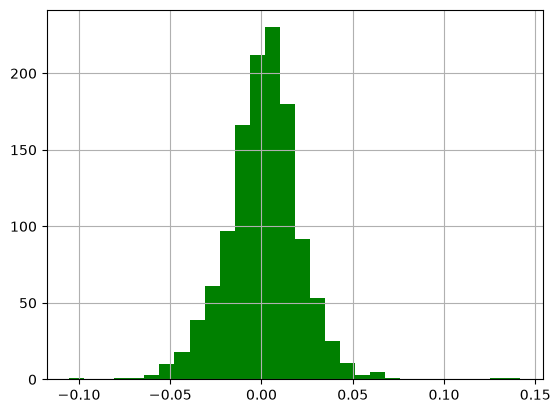

In [57]:
portfolio_returns.hist(bins=30, color="green")

La distribución de los retornos diarios presenta una ligera asimetría positiva (skew = 0.25), lo que sugiere una leve predominancia de eventos positivos extremos. Asimismo, la kurtosis (3.87) supera ligeramente el valor esperado para una distribución normal, indicando la presencia de colas moderadamente pesadas y una mayor probabilidad de observar eventos extremos. Este comportamiento es consistente con el observado habitualmente en series de retornos financieros y justifica el cálculo de métricas adicionales de riesgo, como el Value at Risk y el Expected Shortfall.

### Compound Annual Growth Rate (CAGR)
El Compound Annual Growth Rate (CAGR) representa la tasa de crecimiento anual compuesta de una inversión durante un período determinado.

A diferencia del rendimiento promedio, el CAGR considera el efecto de la capitalización, proporcionando una medida más representativa del crecimiento experimentado por el capital a lo largo del tiempo.

Para el cliente, esta métrica responde a la pregunta:

> ¿A qué tasa anual habría crecido mi inversión si hubiese permanecido invertida durante todo el período analizado?

In [18]:
portfolio_growth = (1 + portfolio_returns).cumprod()

In [19]:
years = len(portfolio_returns) / TRADING_DAYS

cagr = (
    portfolio_growth.iloc[-1]
    ** (1 / years) 
    - 1
)

print(f"CAGR: {cagr:.2%}")

CAGR: 15.28%


### Volatilidad anualizada
La volatilidad anualizada mide la variabilidad de los rendimientos del portafolio y constituye una de las medidas de riesgo más utilizadas en finanzas.

Valores elevados indican una mayor incertidumbre respecto al comportamiento futuro de la inversión, mientras que valores reducidos reflejan un desempeño más estable.

In [20]:
annual_volatility = (
    portfolio_returns.std()
    * np.sqrt(TRADING_DAYS)
)

print(f"Annual Volatility: {annual_volatility:.2%}")

Annual Volatility: 32.51%


### Sharpe ratio
El sharpe evalua el rendimiento obtenido por unidad de riesgo asumido.

Esta metrica compara el exceso de retorno del portafolio sobre la tasa libre de riesgo con la volatilidad experimentada durante el periodo analizado

El Sharpe Ratio mas elevado indica una utilizacion mas eficiente del riesgo para generar ingresos.

In [21]:
annual_return = (
    portfolio_returns.mean()
    * TRADING_DAYS
)

sharpe_ratio = (
    annual_return - RISK_FREE_RATE
) / annual_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 0.48


### Sortino Ratio

El Sortino Ratio constituye una variante del Sharpe Ratio que únicamente considera la volatilidad asociada a los retornos negativos.

Al penalizar exclusivamente el riesgo a la baja, esta métrica proporciona una evaluación más específica del comportamiento del portafolio frente a pérdidas.

In [22]:
downside_returns = portfolio_returns.copy()

downside_returns = downside_returns[
    downside_returns < 0
]

downside_deviation = (
    downside_returns.std()
    * np.sqrt(TRADING_DAYS)
)

sortino_ratio = (
    annual_return - RISK_FREE_RATE
) / downside_deviation

print(f"Sortino Ratio: {sortino_ratio:.2f}")

Sortino Ratio: 0.72


### Resumen de metricas

In [23]:
performance_metrics = pd.DataFrame({
    "Metric": [
        "Compound Annual Growth Rate",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Value": [
        cagr,
        annual_volatility,
        sharpe_ratio,
        sortino_ratio
    ]
})

performance_metrics["Format"] = [
    "percent",
    "percent",
    "decimal",
    "decimal"
]

performance_metrics

,Metric,Value,Format
0,Compound Annual Growth Rate,0.152771,percent
1,Annualized Volatility,0.325050,percent
2,Sharpe Ratio,0.476357,decimal
3,Sortino Ratio,0.721373,decimal


In [48]:
print(sharpe_ratio)

print(sortino_ratio)

0.4763574454733749
0.7213727749022701


El portafolio exhibe una tasa de crecimiento anual compuesta del 15.3%, coherente con una estrategia orientada al crecimiento del capital. Este rendimiento viene acompañado de una volatilidad anualizada del 32.5%, consistente con el perfil agresivo del cliente y con la composición del portafolio, dominada por activos de crecimiento. El Sharpe Ratio (0.48) indica una relación riesgo-retorno aceptable, mientras que el Sortino Ratio (0.72), superior al Sharpe, sugiere que una parte importante de la volatilidad observada proviene de movimientos favorables del mercado y no exclusivamente de pérdidas.

Nota metodológica: Las métricas de desempeño calculadas en este notebook no coinciden necesariamente con las reportadas durante la optimización del Notebook 3. En aquella etapa se utilizaron estimaciones ex ante de retorno y riesgo proporcionadas por el modelo de optimización, mientras que en este notebook las métricas se calculan ex post a partir de la serie histórica de rendimientos del portafolio. Ambas aproximaciones son complementarias: la primera evalúa el desempeño esperado bajo los supuestos del modelo, mientras que la segunda describe el comportamiento observado durante el período histórico analizado.

## **Benchmark Comparison**
Comparacion historica contra el S&P 500.

- Sharpe
- Drawdown
- CAGR

Una estrategia de inversión solo puede evaluarse adecuadamente cuando se compara con una referencia representativa del mercado.

En este proyecto se utiliza el índice **S&P 500** como benchmark, al ser uno de los indicadores más ampliamente utilizados para representar el comportamiento del mercado accionario estadounidense.

La comparación se realiza utilizando las mismas métricas calculadas para el portafolio recomendado, permitiendo evaluar si la estrategia propuesta ofrece una mejor relación entre riesgo y rendimiento que una inversión pasiva en el mercado.

### Construccion del benchmark

In [24]:
benchmark_returns = (
    benchmark_prices
    .pct_change()
    .dropna()
)

benchmark_returns.head()

Ticker,^GSPC
Date,
2021-06-02,0.001447
2021-06-03,-0.003629
2021-06-04,0.008834
2021-06-07,-0.000797
2021-06-08,0.000175


### Metricas

In [25]:
benchmark_growth = (
    1+benchmark_returns
).cumprod()

benchmark_years = (
    len(benchmark_returns) 
    / TRADING_DAYS
)

benchmark_cagr = (
    benchmark_growth.iloc[-1]
    ** (1 / benchmark_years) 
    - 1
)

benchmark_volatility = (
    benchmark_returns.std()
    * np.sqrt(TRADING_DAYS)
)

benchmark_annual_return = (
    benchmark_returns.mean()
    * TRADING_DAYS
)

benchmark_sharpe = (
    benchmark_annual_return 
    - RISK_FREE_RATE
) / benchmark_volatility

benchmark_downside = benchmark_returns[
    benchmark_returns < 0
]

benchmark_sortino = (
    benchmark_annual_return 
    - RISK_FREE_RATE
) / (
    benchmark_downside.std() 
    * np.sqrt(TRADING_DAYS)
)

### Tabla comparativa

In [26]:
benchmark_comparison = pd.DataFrame({
    "Metric": [
        "CAGR",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Portfolio": [
        cagr,
        annual_volatility,
        sharpe_ratio,
        sortino_ratio
    ],
    "S&P 500": [
        benchmark_cagr,
        benchmark_volatility,
        benchmark_sharpe,
        benchmark_sortino
    ]
})

benchmark_comparison

,Metric,Portfolio,S&P 500
0,CAGR,0.152771,Ticker ^GSPC 0.125484 Name: 2026-05-28 00:0...
1,Annualized Volatility,0.325050,Ticker ^GSPC 0.169102 dtype: float64
2,Sharpe Ratio,0.476357,Ticker ^GSPC 0.54707 dtype: float64
3,Sortino Ratio,0.721373,Ticker ^GSPC 0.753293 dtype: float64


In [44]:
benchmark_comparison = benchmark_comparison.set_index("Metric")
print(benchmark_comparison)

                       Portfolio  \
Metric                             
CAGR                    0.152771   
Annualized Volatility   0.325050   
Sharpe Ratio            0.476357   
Sortino Ratio           0.721373   

                                                                 S&P 500  
Metric                                                                    
CAGR                   Ticker
^GSPC    0.125484
Name: 2026-05-28 00:0...  
Annualized Volatility            Ticker
^GSPC    0.169102
dtype: float64  
Sharpe Ratio                      Ticker
^GSPC    0.54707
dtype: float64  
Sortino Ratio                    Ticker
^GSPC    0.753293
dtype: float64  


In [45]:
benchmark_comparison["S&P 500"] = benchmark_comparison["S&P 500"].apply(
    lambda x: x.iloc[0] if isinstance(x, pd.Series) else x
)

In [46]:
print(benchmark_comparison.dtypes)
print(benchmark_comparison)

Portfolio    float64
S&P 500      float64
dtype: object
                       Portfolio   S&P 500
Metric                                    
CAGR                    0.152771  0.125484
Annualized Volatility   0.325050  0.169102
Sharpe Ratio            0.476357  0.547070
Sortino Ratio           0.721373  0.753293


In [47]:
pct_rows = ["CAGR", "Annualized Volatility"]
float_rows = ["Sharpe Ratio", "Sortino Ratio"]

benchmark_comparison.style.format(
    "{:.2%}", subset=pd.IndexSlice[pct_rows, :]
).format(
    "{:.2f}", subset=pd.IndexSlice[float_rows, :]
)

,Portfolio,S&P 500
Metric,,
CAGR,15.28%,12.55%
Annualized Volatility,32.51%,16.91%
Sharpe Ratio,0.48,0.55
Sortino Ratio,0.72,0.75


El portafolio propuesto logra un crecimiento anual compuesto superior al del S&P 500, aunque a costa de asumir una volatilidad significativamente mayor. Desde una perspectiva de eficiencia riesgo-retorno, el benchmark presenta un desempeño ligeramente superior, como reflejan los ratios de Sharpe y Sortino. Esto sugiere que la estrategia diseñada es adecuada únicamente para inversionistas con una alta tolerancia al riesgo y un horizonte de inversión de largo plazo, dispuestos a aceptar una mayor variabilidad en el valor de su cartera a cambio de un mayor potencial de crecimiento.

## **Historical Performance**
- Equity curve
- Rolling Return
- Rolling vollatility
- Drawdowns

Además de las métricas de riesgo y rentabilidad, resulta fundamental analizar la evolución histórica del portafolio a lo largo del tiempo.

En esta sección se reconstruye el comportamiento del capital invertido, permitiendo visualizar los periodos de crecimiento, las caídas temporales y los cambios en el nivel de riesgo del portafolio. Asimismo, estos resultados se comparan con el comportamiento histórico del índice S&P 500 para contextualizar el desempeño de la estrategia propuesta.

### Equity curve

In [48]:
portfolio_equity = INITIAL_CAPITAL * (1 + portfolio_returns).cumprod()

benchmark_equity = INITIAL_CAPITAL * (1 + benchmark_returns).cumprod()

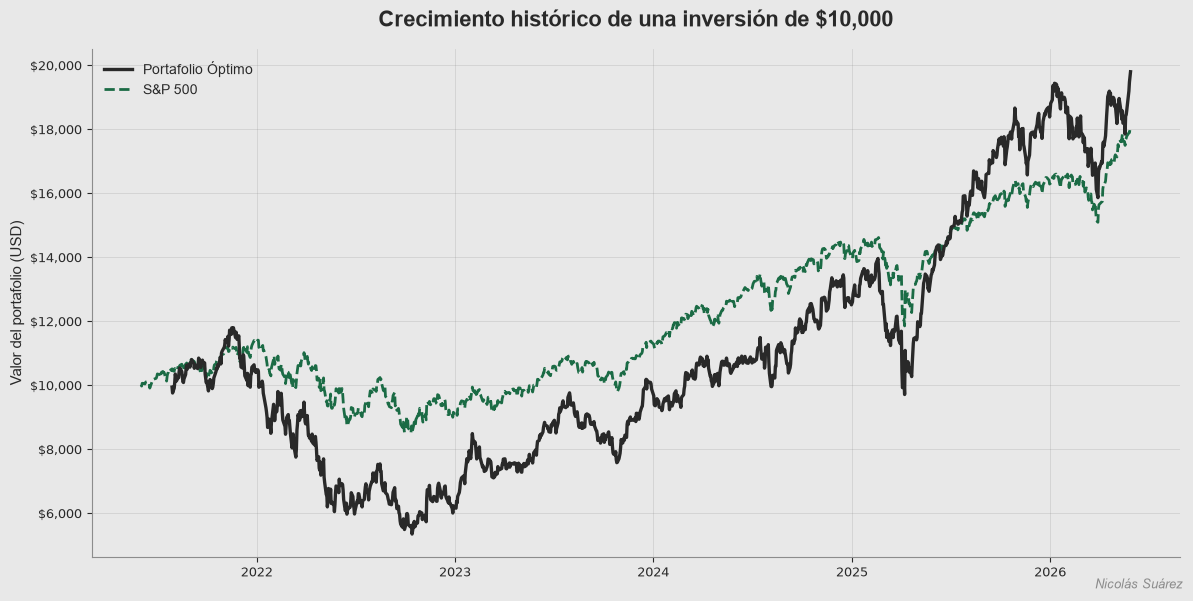

In [60]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(
    portfolio_equity,
    label="Portafolio Óptimo",
    linewidth=2.4,
    color=TEXT,
    zorder=3
)
ax.plot(
    benchmark_equity,
    label="S&P 500",
    linewidth=2,
    color=ACCENT,
    linestyle="--",
    zorder=2
)

ax.set_title(
    "Crecimiento histórico de una inversión de $10,000",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",  
    color=TEXT,
    pad=16
)
ax.set_ylabel("Valor del portafolio (USD)", fontsize=11, color=TEXT, fontfamily="Arial")

# Formato de eje Y como moneda
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Gridlines sutiles, sin spines superior/derecho
ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

# Footer NS
fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

### Rolling returns

In [61]:
rolling_return = (
    (1 + portfolio_returns)
    .rolling(TRADING_DAYS)
    .apply(np.prod, raw=True)
    - 1
)

benchmark_rolling_return = (
    (1 + benchmark_returns)
    .rolling(TRADING_DAYS)
    .apply(np.prod, raw=True)
    - 1
)

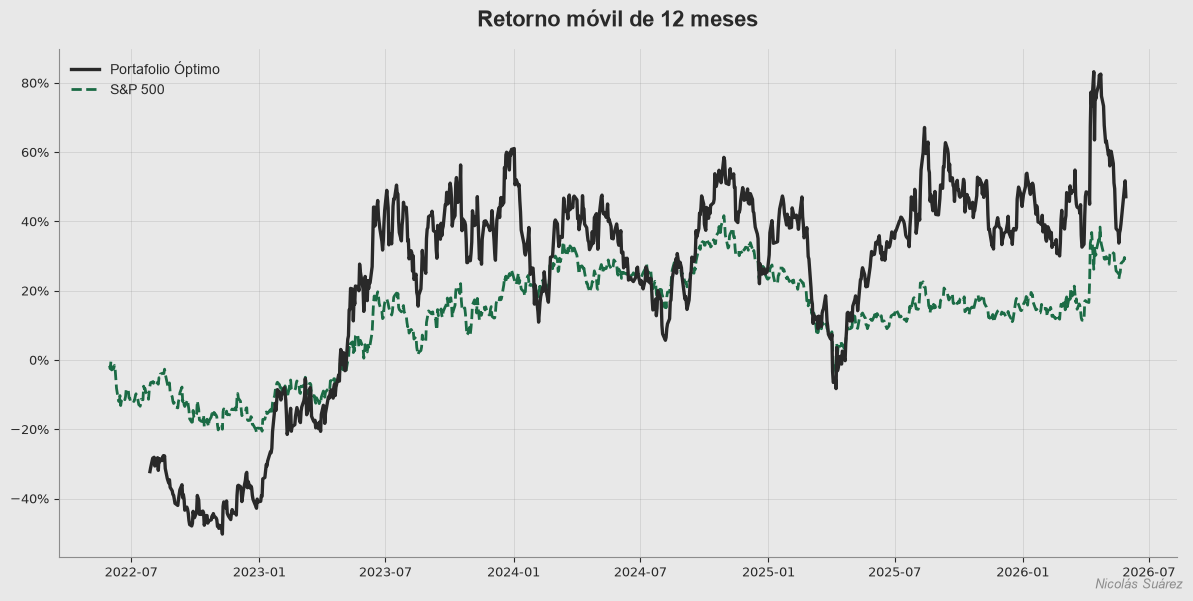

In [62]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(
    rolling_return,
    label="Portafolio Óptimo",
    linewidth=2.4,
    color=TEXT,
    zorder=3
)
ax.plot(
    benchmark_rolling_return,
    label="S&P 500",
    linewidth=2,
    color=ACCENT,
    linestyle="--",
    zorder=2
)

ax.set_title(
    "Retorno móvil de 12 meses",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

### Rolling Volatility

In [63]:
rolling_volatility = (
    portfolio_returns
    .rolling(TRADING_DAYS)
    .std()
    * np.sqrt(TRADING_DAYS)
)

benchmark_rolling_volatility = (
    benchmark_returns
    .rolling(TRADING_DAYS)
    .std()
    * np.sqrt(TRADING_DAYS)
)

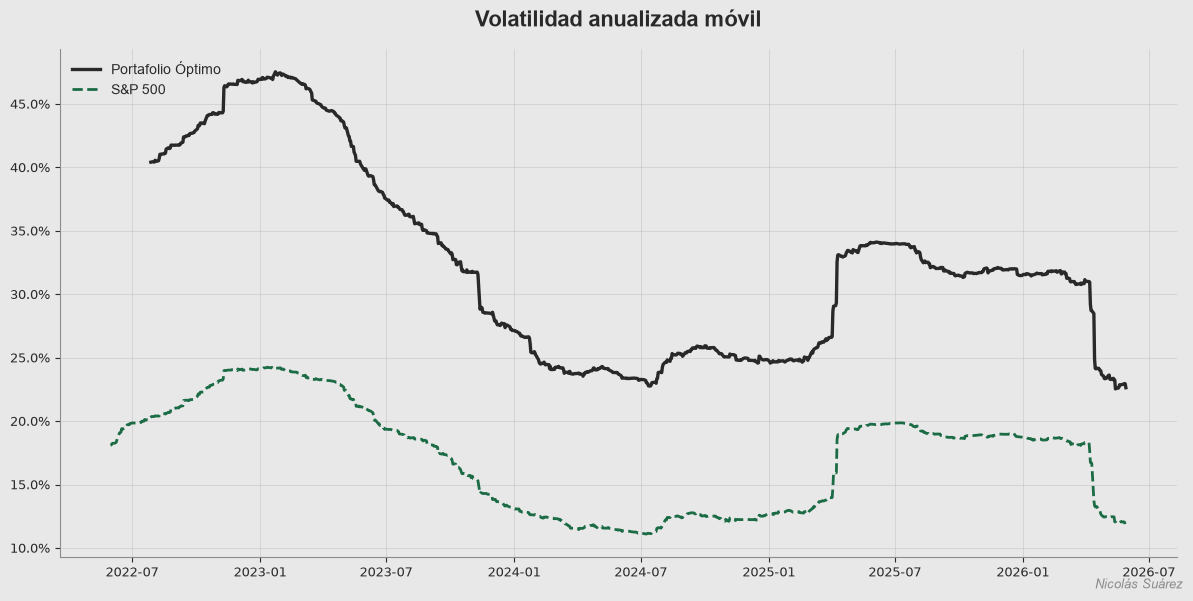

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(
    rolling_volatility,
    label="Portafolio Óptimo",
    linewidth=2.4,
    color=TEXT,
    zorder=3
)
ax.plot(
    benchmark_rolling_volatility,
    label="S&P 500",
    linewidth=2,
    color=ACCENT,
    linestyle="--",
    zorder=2
)

ax.set_title(
    "Volatilidad anualizada móvil",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

### Drawdown analysis

In [65]:

portfolio_peak = portfolio_equity.cummax()

portfolio_drawdown = (
    portfolio_equity
    - portfolio_peak
) / portfolio_peak

benchmark_peak = benchmark_equity.cummax()

benchmark_drawdown = (
    benchmark_equity
    - benchmark_peak
) / benchmark_peak

In [71]:
benchmark_drawdown = benchmark_drawdown.squeeze()

In [69]:
max_drawdown = portfolio_drawdown.min()

benchmark_max_drawdown = benchmark_drawdown.min()

print(f"Portfolio Maximum Drawdown: {max_drawdown}")

print(f"S&P 500 Maximum Drawdown: {benchmark_max_drawdown}")

Portfolio Maximum Drawdown: -0.5464905991838809
S&P 500 Maximum Drawdown: Ticker
^GSPC   -0.254251
dtype: float64


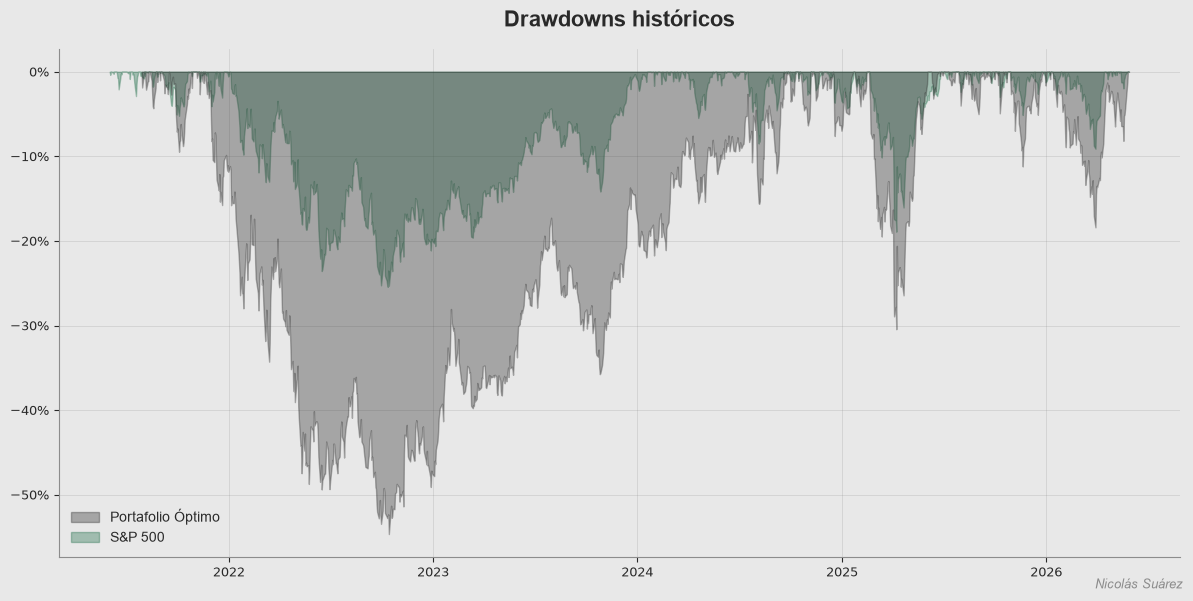

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.fill_between(
    portfolio_drawdown.index,
    portfolio_drawdown,
    0,
    color=TEXT,
    alpha=0.35,
    label="Portafolio Óptimo",
    zorder=3
)
ax.fill_between(
    benchmark_drawdown.index,
    benchmark_drawdown,
    0,
    color=ACCENT,
    alpha=0.35,
    label="S&P 500",
    zorder=2
)

ax.set_title(
    "Drawdowns históricos",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower left",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

## **Tail Risk Analysis**
Las métricas tradicionales, como la volatilidad o el Sharpe Ratio, describen el comportamiento promedio del portafolio. Sin embargo, no proporcionan información suficiente sobre las pérdidas potenciales durante eventos extremos del mercado.

Por ello, en esta sección se analizan dos métricas ampliamente utilizadas en la gestión profesional del riesgo:

- **Value at Risk (VaR):** estima la pérdida máxima esperada bajo condiciones normales de mercado para un determinado nivel de confianza.
- **Expected Shortfall (CVaR):** cuantifica la pérdida promedio cuando las pérdidas superan el umbral definido por el VaR.

En conjunto, estas métricas permiten evaluar la exposición del portafolio a escenarios adversos y complementan las medidas tradicionales de riesgo analizadas anteriormente.

In [73]:
CONFIDENCE_LEVEL = 0.95

### Historical Value at Risk (VaR)

In [74]:
var_95 = np.percentile(
    portfolio_returns,
    (1 - CONFIDENCE_LEVEL) * 100
)

print(f"Historical VaR (95%): {var_95:.2%}")

Historical VaR (95%): -3.33%


El Value at Risk (VaR) al 95% representa la pérdida máxima esperada en un día normal de mercado con un nivel de confianza del 95%.

En otras palabras, existe aproximadamente un 5% de probabilidad de que la pérdida diaria del portafolio sea superior a este valor.

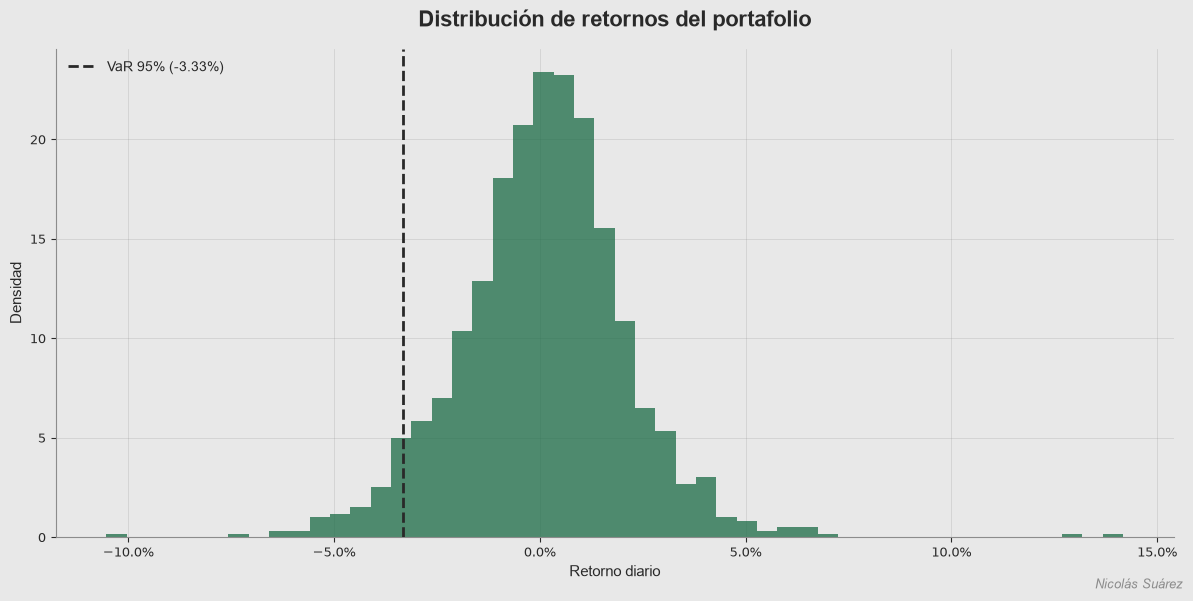

In [75]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.hist(
    portfolio_returns,
    bins=50,
    density=True,
    color=ACCENT,
    alpha=0.75,
    zorder=2
)
ax.axvline(
    var_95,
    color=TEXT,
    linestyle="--",
    linewidth=2,
    label=f"VaR 95% ({var_95:.2%})",
    zorder=3
)

ax.set_title(
    "Distribución de retornos del portafolio",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)
ax.set_xlabel("Retorno diario", fontsize=11, color=TEXT, fontfamily="Arial")
ax.set_ylabel("Densidad", fontsize=11, color=TEXT, fontfamily="Arial")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

### Expected Shortfall (CVaR)

In [76]:
cvar_95 = portfolio_returns[
    portfolio_returns <= var_95
].mean()

print(f"Expected Shortfall (95%): {cvar_95:.2%}")

Expected Shortfall (95%): -4.39%


Mientras que el VaR indica el umbral a partir del cual comienzan los eventos extremos, el Expected Shortfall (CVaR) estima la pérdida promedio cuando dichos eventos efectivamente ocurren.

Por esta razón, el CVaR suele considerarse una medida más conservadora del riesgo extremo y es ampliamente utilizada en instituciones financieras y organismos reguladores.

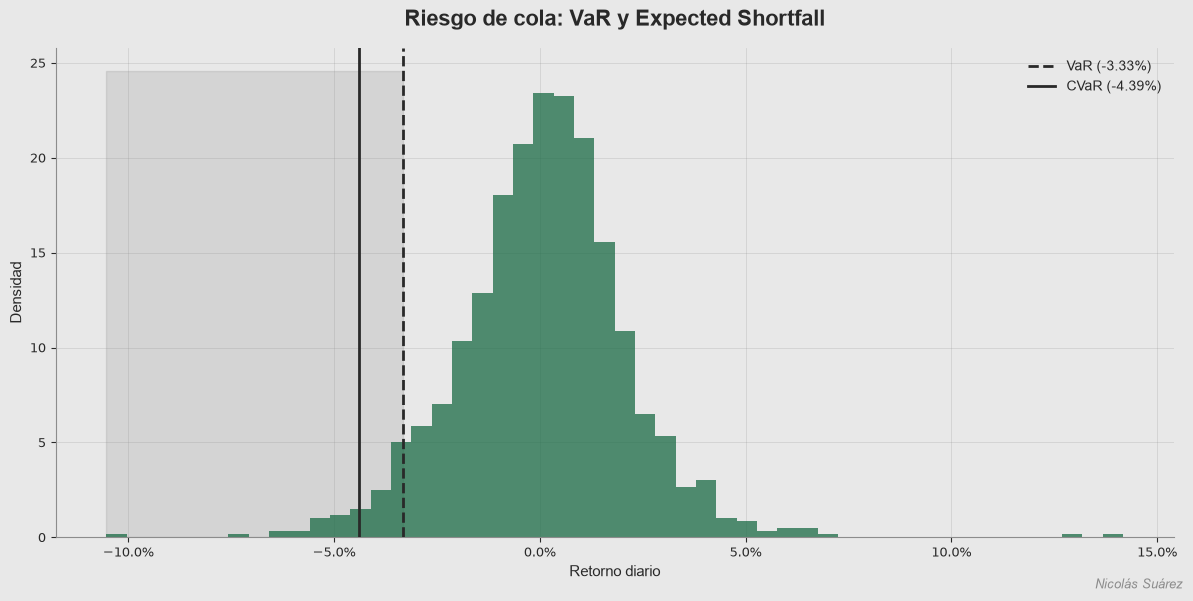

In [77]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.hist(
    portfolio_returns,
    bins=50,
    density=True,
    color=ACCENT,
    alpha=0.75,
    zorder=2
)

ax.axvline(
    var_95,
    color=TEXT,
    linestyle="--",
    linewidth=2,
    label=f"VaR ({var_95:.2%})",
    zorder=3
)
ax.axvline(
    cvar_95,
    color=TEXT,
    linestyle="-",
    linewidth=2,
    label=f"CVaR ({cvar_95:.2%})",
    zorder=3
)

ax.fill_betweenx(
    [0, ax.get_ylim()[1]],
    portfolio_returns.min(),
    var_95,
    color=TEXT,
    alpha=0.1,
    zorder=1
)

ax.set_title(
    "Riesgo de cola: VaR y Expected Shortfall",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)
ax.set_xlabel("Retorno diario", fontsize=11, color=TEXT, fontfamily="Arial")
ax.set_ylabel("Densidad", fontsize=11, color=TEXT, fontfamily="Arial")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

In [78]:
tail_risk_summary = pd.DataFrame({
    "Metric": [
        "Historical VaR (95%)",
        "Expected Shortfall (95%)"
    ],
    "Value": [
        var_95,
        cvar_95
    ]
})

tail_risk_summary

,Metric,Value
0,Historical VaR (95%),-0.033294
1,Expected Shortfall (95%),-0.043939


### Benchmark comparison

In [79]:
benchmark_var_95 = np.percentile(
    benchmark_returns,
    (1 - CONFIDENCE_LEVEL) * 100
)

benchmark_cvar_95 = benchmark_returns[
    benchmark_returns <= benchmark_var_95
].mean()

In [80]:
tail_risk_comparison = pd.DataFrame({
    "Metric": [
        "Historical VaR (95%)",
        "Expected Shortfall (95%)"
    ],
    "Portfolio": [
        var_95,
        cvar_95
    ],
    "S&P 500": [
        benchmark_var_95,
        benchmark_cvar_95
    ]
})

tail_risk_comparison

,Metric,Portfolio,S&P 500
0,Historical VaR (95%),-0.033294,-0.016426
1,Expected Shortfall (95%),-0.043939,Ticker ^GSPC -0.024407 dtype: float64


In [82]:
tail_risk_comparison["S&P 500"] = tail_risk_comparison["S&P 500"].apply(
    lambda x: x.iloc[0] if isinstance(x, pd.Series) else x
)

In [83]:
tail_risk_comparison_display = tail_risk_comparison.copy()

for column in ["Portfolio", "S&P 500"]:
    tail_risk_comparison_display[column] = (
        tail_risk_comparison_display[column]
        .apply(lambda x: f"{x:.2%}")
    )

tail_risk_comparison_display

,Metric,Portfolio,S&P 500
0,Historical VaR (95%),-3.33%,-1.64%
1,Expected Shortfall (95%),-4.39%,-2.44%


El análisis de riesgo extremo muestra que el portafolio recomendado presenta una mayor exposición a pérdidas severas que el S&P 500. Con un nivel de confianza del 95%, la pérdida diaria máxima esperada bajo condiciones normales de mercado es de aproximadamente 3.33%, frente al 1.64% observado para el benchmark. Asimismo, cuando ocurren eventos más extremos que el VaR, la pérdida promedio (Expected Shortfall) asciende al 4.39% para el portafolio, mientras que el S&P 500 registra una pérdida promedio del 2.44%. Estos resultados son coherentes con la composición del portafolio, dominada por acciones de crecimiento y alta volatilidad, y con el perfil agresivo del cliente, quien prioriza el crecimiento del capital sobre la estabilidad de corto plazo.

## **Monte Carlo Projection**
Proyeccion futura del capital durante los proximos 10 años.

Las métricas históricas permiten comprender cómo se comportó el portafolio durante el período analizado. Sin embargo, un inversionista también necesita evaluar cómo podría evolucionar su inversión en el futuro bajo distintos escenarios posibles.

Para ello, se utiliza una simulación de Monte Carlo basada en un proceso de Movimiento Browniano Geométrico (Geometric Brownian Motion, GBM), ampliamente empleado en finanzas para modelar la evolución de activos financieros.

El objetivo no es predecir el futuro, sino generar un conjunto de trayectorias plausibles que permitan cuantificar la incertidumbre asociada al crecimiento del capital durante el horizonte de inversión del cliente.

### Parametros de simulacion

In [84]:
N_SIMULATIONS = 10_000

N_YEARS = INVESTMENT_HORIZON

N_STEPS = TRADING_DAYS * N_YEARS

DT = 1 / TRADING_DAYS

### Parametros del portafolio

In [85]:
mu = portfolio_returns.mean() * TRADING_DAYS

sigma = portfolio_returns.std() * np.sqrt(TRADING_DAYS)

print(mu)

print(sigma)

0.19484018558294694
0.32505041551114255


### Simulacion

In [86]:
simulation_paths = np.zeros(
    (N_STEPS + 1, N_SIMULATIONS)
)

simulation_paths[0] = INITIAL_CAPITAL

for simulation in range(N_SIMULATIONS):

    for t in range(1, N_STEPS + 1):

        z = np.random.normal()

        simulation_paths[t, simulation] = (
            simulation_paths[t-1, simulation]
            * np.exp(
                (
                    mu
                    - 0.5 * sigma**2
                ) * DT
                + sigma
                * np.sqrt(DT)
                * z
            )
        )

### Trayectorias

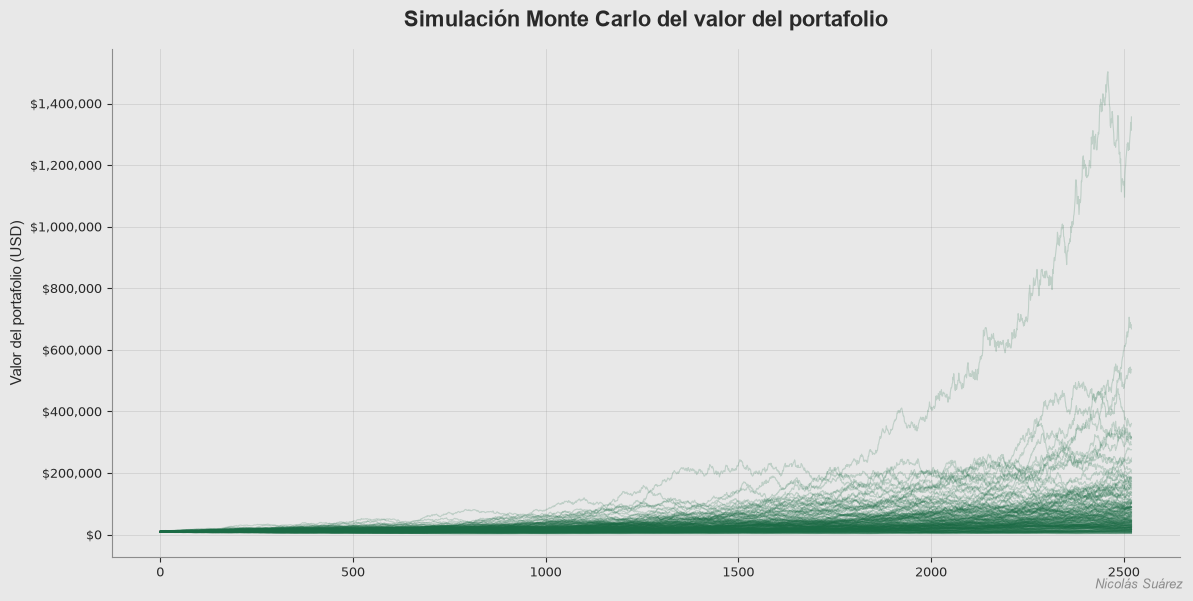

In [88]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(
    simulation_paths[:, :200],
    linewidth=0.8,
    alpha=0.2,
    color=ACCENT,
    zorder=2
)

ax.set_title(
    "Simulación Monte Carlo del valor del portafolio",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)
ax.set_ylabel("Valor del portafolio (USD)", fontsize=11, color=TEXT, fontfamily="Arial")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

### Distribucion del valor final

In [89]:
final_values = simulation_paths[-1]

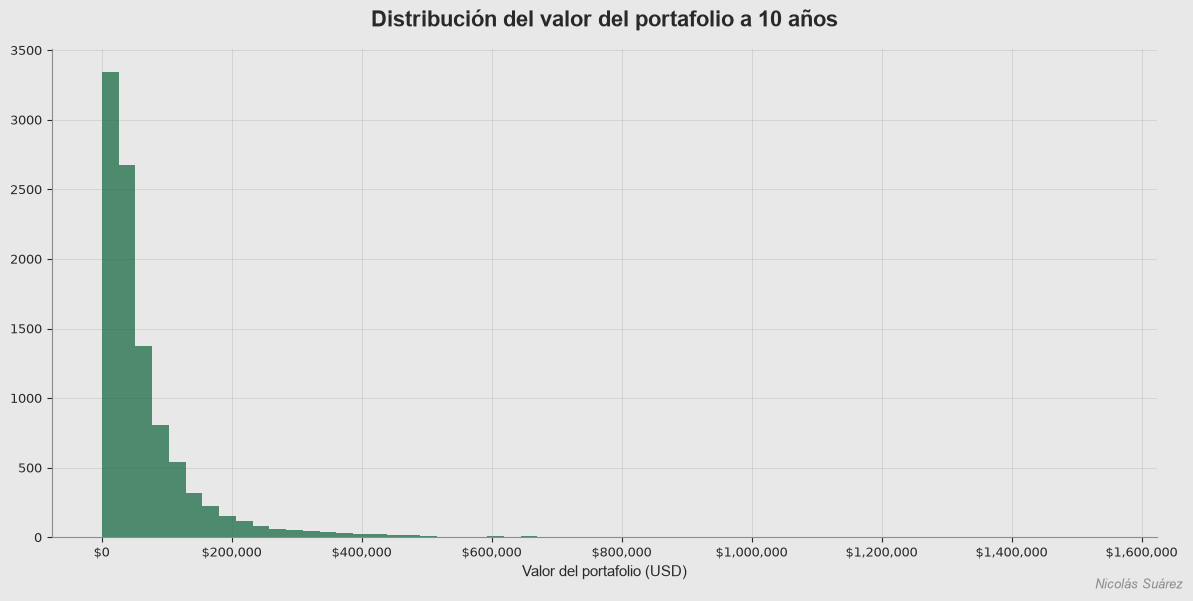

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.hist(
    final_values,
    bins=60,
    color=ACCENT,
    alpha=0.75,
    zorder=2
)

ax.set_title(
    "Distribución del valor del portafolio a 10 años",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)
ax.set_xlabel("Valor del portafolio (USD)", fontsize=11, color=TEXT, fontfamily="Arial")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

### Percentiles

In [91]:
p5 = np.percentile(final_values,5)

median = np.percentile(final_values,50)

p95 = np.percentile(final_values,95)

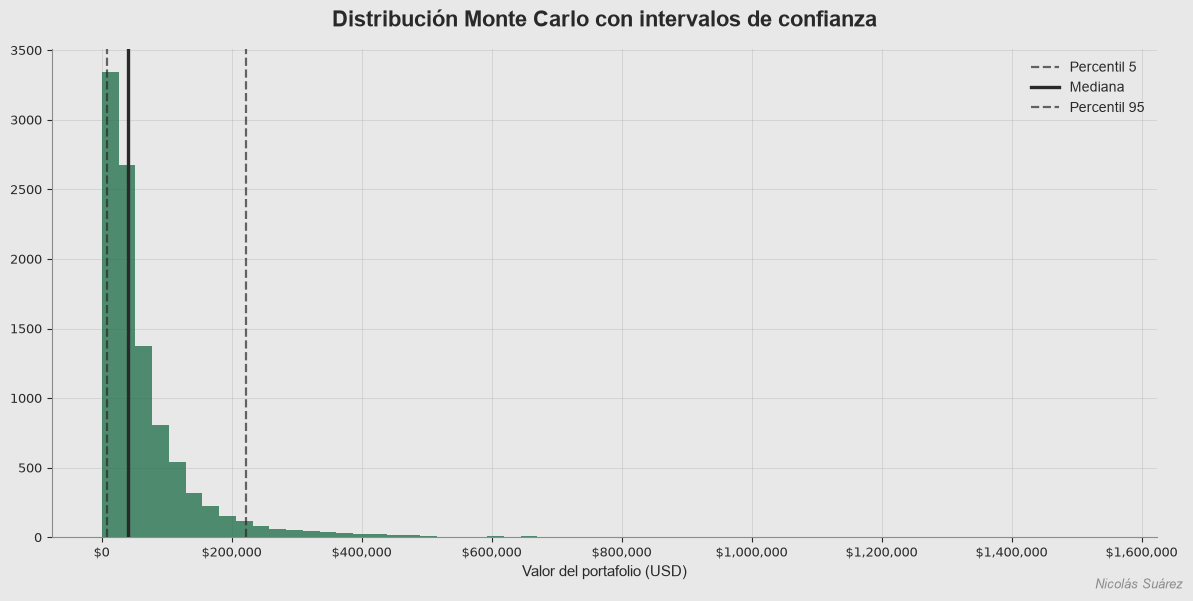

In [92]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.hist(
    final_values,
    bins=60,
    color=ACCENT,
    alpha=0.75,
    zorder=2
)

ax.axvline(
    p5,
    color=TEXT,
    linestyle="--",
    linewidth=1.6,
    alpha=0.7,
    label="Percentil 5",
    zorder=3
)
ax.axvline(
    median,
    color=TEXT,
    linestyle="-",
    linewidth=2.4,
    label="Mediana",
    zorder=3
)
ax.axvline(
    p95,
    color=TEXT,
    linestyle="--",
    linewidth=1.6,
    alpha=0.7,
    label="Percentil 95",
    zorder=3
)

ax.set_title(
    "Distribución Monte Carlo con intervalos de confianza",
    fontsize=16,
    fontweight="bold",
    fontfamily="Arial",
    color=TEXT,
    pad=16
)
ax.set_xlabel("Valor del portafolio (USD)", fontsize=11, color=TEXT, fontfamily="Arial")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.grid(alpha=0.25, color=GREY, linewidth=0.6)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GREY)

ax.tick_params(colors=TEXT, labelsize=9)

legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right",
    prop={"family": "Arial"}
)
for text in legend.get_texts():
    text.set_color(TEXT)

fig.text(
    0.99, 0.01,
    "Nicolás Suárez",
    fontsize=9,
    color=GREY,
    ha="right",
    style="italic",
    fontfamily="Arial"
)

plt.tight_layout()
plt.show()

In [93]:
probability_of_loss = (
    final_values < INITIAL_CAPITAL
).mean()

In [94]:
monte_carlo_summary = pd.DataFrame({
    "Metric":[
        "Expected Final Value",
        "Median Final Value",
        "5th Percentile",
        "95th Percentile",
        "Probability of Loss"
    ],
    "Value":[
        final_values.mean(),
        median,
        p5,
        p95,
        probability_of_loss
    ]
})

monte_carlo_summary

,Metric,Value
0,Expected Final Value,69027.834981
1,Median Final Value,40355.666779
2,5th Percentile,7673.958336
3,95th Percentile,221412.470660
4,Probability of Loss,0.085700


La simulación desarrollada en este proyecto utiliza un proceso de Movimiento Browniano Geométrico (Geometric Brownian Motion, GBM), uno de los modelos más empleados para representar la evolución de activos financieros.

Este modelo presenta varias hipótesis importantes que deben considerarse al interpretar los resultados:

- Los retornos siguen una distribución aproximadamente normal.
- El rendimiento esperado y la volatilidad permanecen constantes durante todo el horizonte de inversión.
- Los movimientos diarios son independientes entre sí.
- El valor del portafolio nunca puede ser negativo, ya que el modelo utiliza una función exponencial para describir la evolución del capital. En consecuencia, la distribución de los valores finales presenta una cola larga hacia la derecha y un límite inferior cercano a cero.

Por estas razones, la simulación no debe interpretarse como una predicción exacta del futuro, sino como una herramienta para explorar escenarios plausibles bajo un conjunto específico de supuestos.

La simulación de Monte Carlo muestra una distribución fuertemente asimétrica hacia la derecha, característica de los modelos basados en Movimiento Browniano Geométrico. Mientras que el valor esperado del portafolio al final del horizonte de inversión asciende a aproximadamente USD 69,000, la mediana se sitúa alrededor de USD 40,000, lo que indica que unos pocos escenarios excepcionalmente favorables elevan significativamente el promedio. Asimismo, el percentil 5 muestra que, incluso bajo escenarios adversos, el capital final sería cercano a USD 7,700, mientras que solo existe una probabilidad aproximada del 8.6% de finalizar el horizonte de inversión con un valor inferior al capital inicialmente invertido. En conjunto, estos resultados son consistentes con un perfil de inversión agresivo: existe un potencial significativo de crecimiento acompañado de una baja, aunque no despreciable, probabilidad de pérdidas a largo plazo.

## **Entregables**

In [95]:
portfolio_returns.to_frame(
    "portfolio_return"
).to_csv(
    REPORTS_PATH / "portfolio_returns.csv"
)

In [96]:
portfolio_equity.to_frame(
    "portfolio_value"
).to_csv(
    REPORTS_PATH / "portfolio_equity_curve.csv"
)

In [97]:
performance_metrics.to_csv(
    REPORTS_PATH / "risk_metrics.csv",
    index=False
)

In [98]:
benchmark_comparison.to_csv(
    REPORTS_PATH / "benchmark_comparison.csv",
    index=False
)

In [99]:
tail_risk_comparison.to_csv(
    REPORTS_PATH / "tail_risk_comparison.csv",
    index=False
)

In [100]:
portfolio_drawdown.to_frame(
    "drawdown"
).to_csv(
    REPORTS_PATH / "historical_drawdowns.csv"
)

In [101]:
pd.DataFrame(
    simulation_paths
).to_csv(
    REPORTS_PATH / "monte_carlo_projection.csv",
    index=False
)

In [102]:
monte_carlo_summary.to_csv(
    REPORTS_PATH / "monte_carlo_summary.csv",
    index=False
)

## **Business Recomendations**

Con base en los resultados obtenidos durante el proceso de optimización y análisis de riesgo, se recomienda al cliente adoptar el portafolio de **Máximo Sharpe con restricciones**, ya que ofrece el mejor equilibrio entre crecimiento esperado y diversificación dentro del universo de activos analizado.

El portafolio presenta un **Compound Annual Growth Rate (CAGR) histórico del 15.28%**, superior al observado para el índice S&P 500 durante el mismo período. Sin embargo, este mayor potencial de crecimiento viene acompañado de una volatilidad significativamente más elevada, así como de mayores pérdidas potenciales bajo escenarios extremos, reflejadas en las métricas de Value at Risk (VaR) y Expected Shortfall (CVaR).

La simulación de Monte Carlo muestra que, para un horizonte de inversión de diez años, el escenario más probable implica un crecimiento considerable del capital inicial, aunque existe una probabilidad aproximada del **8.6%** de finalizar el período con un valor inferior al monto invertido. Estos resultados son consistentes con un perfil de inversión agresivo y una estrategia orientada al crecimiento de largo plazo.

Finalmente, se recomienda realizar un **rebalanceo periódico del portafolio** (por ejemplo, anual o semestral) con el fin de mantener las ponderaciones objetivo y controlar el nivel de riesgo asumido a medida que evolucionan las condiciones del mercado.

## **Conclusiones**

El presente proyecto tuvo como objetivo diseñar y evaluar un portafolio de inversión para un cliente con alta tolerancia al riesgo y un horizonte de inversión de diez años, utilizando herramientas de optimización de portafolios y análisis cuantitativo de riesgos.

La metodología permitió identificar una cartera diversificada con un potencial de crecimiento superior al benchmark analizado. No obstante, dicho rendimiento adicional implica asumir una volatilidad considerablemente mayor y una mayor exposición a pérdidas extremas, lo que evidencia el compromiso inherente entre riesgo y retorno en estrategias de crecimiento.

Durante el desarrollo del proyecto también se identificaron importantes limitaciones metodológicas. En particular, se documentó la sensibilidad de la optimización de Markowitz a las estimaciones de retornos esperados (Error Maximization) y las hipótesis implícitas del modelo de Movimiento Browniano Geométrico utilizado en la simulación de Monte Carlo. Estos aspectos refuerzan la importancia de interpretar los resultados dentro de su contexto y comprender que los modelos cuantitativos constituyen herramientas de apoyo para la toma de decisiones, y no mecanismos capaces de predecir el comportamiento futuro de los mercados.

Como líneas de trabajo futuras, el análisis podría ampliarse incorporando modelos más robustos para la estimación de retornos esperados, como Black-Litterman o métodos de Bayesian Shrinkage, simulaciones mediante Bootstrap o modelos GARCH, costos de transacción, impuestos y estrategias dinámicas de rebalanceo. Estas mejoras permitirían aproximar aún más el análisis a las prácticas utilizadas en la gestión profesional de portafolios.

La optimización de portafolios no consiste en encontrar el portafolio perfecto, sino en construir una estrategia de inversión coherente con los objetivos, restricciones y tolerancia al riesgo del inversionista. Los modelos matemáticos proporcionan una base cuantitativa para la toma de decisiones, pero el criterio profesional del analista sigue siendo indispensable para interpretar sus resultados y comprender sus limitaciones.